In [44]:
import os
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import stylia as st
from stylia import (
    ONE_COLUMN_WIDTH,
    TWO_COLUMNS_WIDTH,
    NamedColorMaps,
    NamedColors,
    ContinuousColorMap,
)
from sklearn.metrics import roc_curve, auc

data_dir = "../data/"
model_dir = "../models/"
figure_dir = "../figures/"

In [45]:
#plotting functions
def plot_roc_curve(ax, name):
    with open(os.path.join(model_dir, f"{name}", "report.json"), 'r') as f:
        results = json.load(f)
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    for i in results.keys():
        y_hat = results[i]['y_hat']
        y_true = results[i]['y_true']
        fpr, tpr, _ = roc_curve(y_true, y_hat)
        roc_auc = auc(fpr, tpr)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)
        aucs.append(roc_auc)
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    ax.plot(mean_fpr, mean_tpr, color='b',
            label=r'Mean ROC (AUC = {:.2f} $\pm$ {:.2f})'.format(mean_auc, std_auc),
            lw=1, alpha=1)
    ax.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color='gray', alpha=0.5,
                    label=r'$\pm$ 1 std. dev.')
    ax.set_title(f"AUROC {mean_auc:.2f} {name}")
    ax.set_xlabel("")
    ax.set_ylabel("")

In [46]:
def plot_yhat(ax,name):
    with open(os.path.join(model_dir, f"{name}", "report.json"), 'r') as f:
        results = json.load(f)
    y_hat = np.array(results["0"]['y_hat'])
    y_true = np.array(results["0"]['y_true'])
    y_hats_1 = y_hat[y_true == 1]
    y_hats_0 = y_hat[y_true == 0]
    np.random.shuffle(y_hats_0)
    np.random.shuffle(y_hats_1)

    for y in zip(y_hats_0):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().gray
        ax.scatter([0 + jitter], [y], color=color, alpha=0.5)

    for y in zip(y_hats_1):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().red
        ax.scatter([1 + jitter], [y], color=color, alpha=0.5)

    ax.set_xticks([0,1])
    ax.set_xticklabels(["Neg", "Pos"])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(name)

In [47]:
def plot_yhat_negtest(ax,name, test):
    with open(os.path.join(model_dir, f"{name}", "report.json"), 'r') as f:
        results = json.load(f)
    y_hat = np.array(results["0"]['y_hat'])
    y_true = np.array(results["0"]['y_true'])
    y_hats_1 = y_hat[y_true == 1]
    y_hats_0 = y_hat[y_true == 0]
    np.random.shuffle(y_hats_0)
    np.random.shuffle(y_hats_1)

    for y in zip(y_hats_0):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().gray
        ax.scatter([0 + jitter], [y], color=color, alpha=0.5)

    for y in zip(y_hats_1):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().red
        ax.scatter([1 + jitter], [y], color=color, alpha=0.5)
    with open(os.path.join(data_dir, "prediction_sets", f"{test}", "results.json"), "r") as f:
        results = json.load(f)
    y_hat_test = np.array(results['y_hat'])
    for y in zip(y_hat_test):
        jitter = np.random.uniform(-0.1, 0.1)
        color = NamedColors().green
        ax.scatter([0 + jitter], [y], color=color, alpha=0.5)
    ax.set_xticks([0,1])
    ax.set_xticklabels(["Neg", "Pos"])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(name)

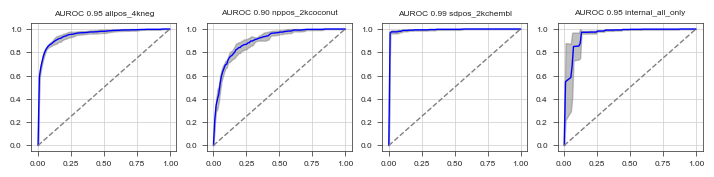

In [48]:
# plot AUROCS for 5-fold crossvalidation of models with ALL data

fig, axs = st.create_figure(1,4, width=TWO_COLUMNS_WIDTH, height = ONE_COLUMN_WIDTH/2)

ax = axs.next()
plot_roc_curve(ax, "allpos_4kneg")
ax = axs.next()
plot_roc_curve(ax, "nppos_2kcoconut")
ax = axs.next()
plot_roc_curve(ax, "sdpos_2kchembl")
ax = axs.next()
plot_roc_curve(ax, "internal_all_only")
plt.tight_layout()
st.save_figure(os.path.join(figure_dir, "auroc_all_small.png"))


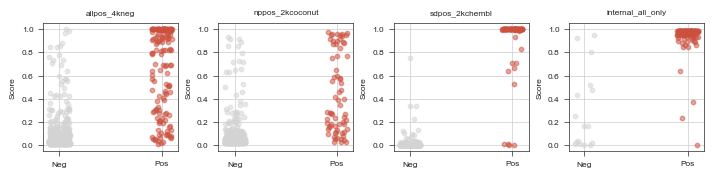

In [49]:
# plot example values
fig, axs = st.create_figure(1,4, width=TWO_COLUMNS_WIDTH, height = ONE_COLUMN_WIDTH/2)

ax = axs.next()
plot_yhat(ax, "allpos_4kneg")
ax = axs.next()
plot_yhat(ax, "nppos_2kcoconut")
ax = axs.next()
plot_yhat(ax, "sdpos_2kchembl")
ax = axs.next()
plot_yhat(ax, "internal_all_only")
plt.tight_layout()
st.save_figure(os.path.join(figure_dir, "yhats_all_small.png"))

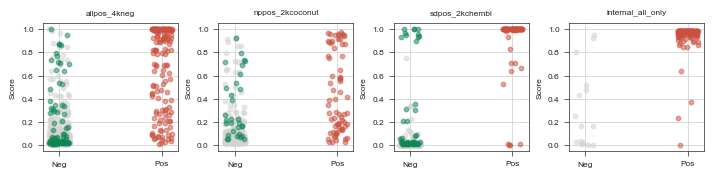

In [50]:
# plot example values
fig, axs = st.create_figure(1,4, width=TWO_COLUMNS_WIDTH, height = ONE_COLUMN_WIDTH/2)

ax = axs.next()
plot_yhat_negtest(ax, "allpos_4kneg", "internal_all_negs_allpos_4kneg")
ax = axs.next()
plot_yhat_negtest(ax, "nppos_2kcoconut", "internal_np_negs_nppos_2kcoconut")
ax = axs.next()
plot_yhat_negtest(ax, "sdpos_2kchembl", "internal_sd_negs_sdpos_2kchembl")
ax = axs.next()
plot_yhat(ax, "internal_all_only")
plt.tight_layout()
st.save_figure(os.path.join(figure_dir, "yhats_val_all_small.png"))

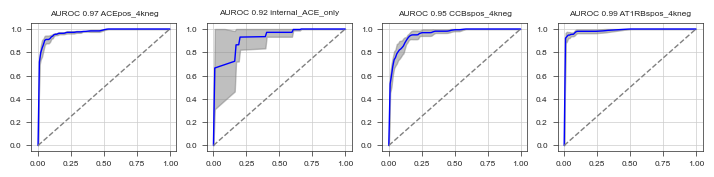

In [51]:
# AUROCS for Target data
fig, axs = st.create_figure(1,4, width=TWO_COLUMNS_WIDTH, height = ONE_COLUMN_WIDTH/2)
ax = axs.next()
plot_roc_curve(ax, "ACEpos_4kneg")
ax = axs.next()
plot_roc_curve(ax, "internal_ACE_only")
ax = axs.next()
plot_roc_curve(ax, "CCBspos_4kneg")
ax = axs.next()
plot_roc_curve(ax, "AT1RBspos_4kneg")
plt.tight_layout()
st.save_figure(os.path.join(figure_dir, "auroc_target_small.png"))

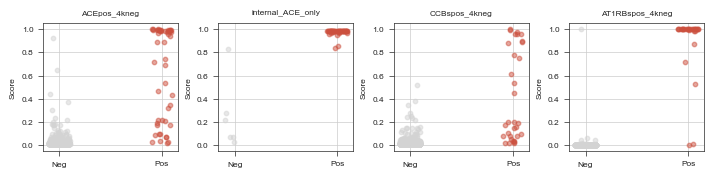

In [52]:
# plot example values
fig, axs = st.create_figure(1,4, width=TWO_COLUMNS_WIDTH, height = ONE_COLUMN_WIDTH/2)

ax = axs.next()
plot_yhat(ax, "ACEpos_4kneg")
ax = axs.next()
plot_yhat(ax, "internal_ACE_only")
ax = axs.next()
plot_yhat(ax, "CCBspos_4kneg")
ax = axs.next()
plot_yhat(ax, "AT1RBspos_4kneg")
plt.tight_layout()
st.save_figure(os.path.join(figure_dir, "yhats_target_small.png"))

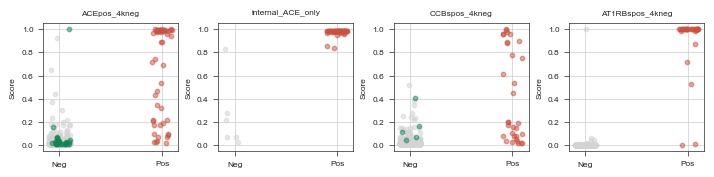

In [53]:
# plot example values
fig, axs = st.create_figure(1,4, width=TWO_COLUMNS_WIDTH, height = ONE_COLUMN_WIDTH/2)

ax = axs.next()
plot_yhat_negtest(ax, "ACEpos_4kneg", "internal_ACE_negs_ACEpos_4kneg")
ax = axs.next()
plot_yhat(ax, "internal_ACE_only")
ax = axs.next()
plot_yhat_negtest(ax, "CCBspos_4kneg", "internal_CCBs_negs_CCBspos_4kneg")
ax = axs.next()
plot_yhat(ax, "AT1RBspos_4kneg")
plt.tight_layout()
st.save_figure(os.path.join(figure_dir, "yhats_val_target_small.png"))